# Basin Delineation Test Code

## Importing Packages

In [1]:
# !pip install pysheds netCDF4 fiona geopandas xarray pyshp

In [1]:
# IMPORT PACKAGES
import pysheds
from pysheds.grid import Grid
import matplotlib.pyplot as plt
import matplotlib.colors as colors
from matplotlib.colors import ListedColormap, BoundaryNorm
import geopandas as gpd
import rasterio
import numpy as np
import pandas as pd
import fiona
import xarray as xr
import shapefile
import math
from scipy import stats
import os
from numpy import random
import netCDF4 as nc
from netCDF4 import Dataset
from shapely.geometry import Point, shape, box, mapping, Polygon, MultiPolygon
from shapely.vectorized import contains
from shapely.strtree import STRtree
import matplotlib.path as mpath

from rasterio.transform import rowcol
from rasterio.coords import BoundingBox
from rasterio.mask import mask
from rasterio.plot import show
from rasterio.features import shapes

## Define Functions

### Crop Continent-Scale DEM

In [2]:
def crop_dem(input_tif, output_tif, center_lon, center_lat,area):
    """
    Crop a GeoTIFF file around a specified coordinate (center_lon, center_lat), save the cropped image,
    display the cropped area, and plot a scatter point at the center coordinates.
    """

    # # Define the path to the input and output TIFF files
    # input_tiff = "path/to/your/input.tif"
    # output_tif = "path/to/your/output_cropped.tif"
    if area < 10000:
      width = np.sqrt(area)*4 # width extending from center point to each edge of square
    else:
      width = np.sqrt(area)*2

    width = int(width)
    degrees = np.round(width/111.32,2)

    xmin = center_lon - degrees
    xmax = center_lon + degrees
    ymin = center_lat - degrees
    ymax = center_lat + degrees

    # Define the bounding box coordinates (left, bottom, right, top)
    bbox = (xmin, ymin, xmax, ymax)  # Replace with actual coordinates

    # Open the source TIFF file
    with rasterio.open(input_tif) as src:
        # Convert the bounding box to a GeoJSON-style geometry for rasterio.mask.mask
        bbox_geom = {
            "type": "Polygon",
            "coordinates": [[
                [bbox[0], bbox[1]],
                [bbox[0], bbox[3]],
                [bbox[2], bbox[3]],
                [bbox[2], bbox[1]],
                [bbox[0], bbox[1]]
            ]]
        }

        # Crop the image using the bounding box geometry
        out_image, out_transform = mask(src, [bbox_geom], crop=True)
        out_meta = src.meta.copy()

        # Update metadata to reflect the new cropped area
        out_meta.update({
            "driver": "GTiff",
            "height": out_image.shape[1],
            "width": out_image.shape[2],
            "transform": out_transform,
            'crs': src.crs  # Ensure the CRS remains the same
        })

        # # Save the cropped data to a new GeoTIFF file with updated profile
        # profile = src.profile
        # profile.update({
        #     'height': height,
        #     'width': width,
        #     'transform': transform,
        #     'crs': src.crs  # Ensure CRS is preserved
        # })

        #with rasterio.open(output_tif, 'w', **out_meta) as dst:
        #    dst.write(out_image)


    fig, ax = plt.subplots(figsize=(10, 10))

    # Calculate the extent of the image in geographic coordinates
    left = out_transform.c  # xmin
    right = out_transform.c + out_transform.a * out_image.shape[2]  # xmax
    top = out_transform.f  # ymax
    bottom = out_transform.f + out_transform.e * out_image.shape[1]  # ymin

    extent = (left, right, bottom, top)

    # Plot the image using rasterio's show function
    show(out_image, transform=out_transform, extent=extent, ax=ax, cmap='gray')
    # Set axis labels
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    # Add a scatter point at the center coordinate
    plt.scatter(lon, lat, color='red', marker='o', s=100, label="Center Point")
    plt.title("Cropped GeoTIFF Area with Center Point")
    plt.title("Cropped Image")
    plt.show()

## Define Filepaths and Open Station Masterfile


In [3]:
# DEFINE INPUTS FOR FUNCTION
masterlist = '/global/scratch/users/cgerlein/fc_ecohydrology_scratch/CSMUB/DATA/GRDC_Stations_AllMonthly.csv'

In [5]:
# Create a dataframe of all the stations
stations_df = pd.read_csv(masterlist)
# print(stations_df)

# # Optional: Create a random subset for testing
# indx = random.randint(0, len(stations_df), size=50)
# indx = np.sort(indx)
# print(indx)
# stations_df = df.iloc[indx]

station_num = stations_df['grdc_no']
shp_log = np.zeros(len(station_num)) 

print(f"Loaded {len(station_num)} stations.")

Loaded 575 stations.


## Crop Continent-Scale DEM

In [81]:
# Generate a random integer between 0 and 49 for the fifty random test samples
# i = random.randint(0,49)
# print(i)
i = 506 # this was a random integer, I just saved it to keep looking at the same basin for testing

In [82]:
# Load the specific station data and save information
# for i in range(0):
data = stations_df.iloc[i]
# print(data)
number = data['grdc_no']
region = data['wmo_reg']
lat = data['lat']
lon = data['long']
area = data['area']

print(number)
print(region)
print(lon,lat)

# determine what continent DEM to use
# 1 - africa, 2 - asia, 3 - SA, 4 - NA/CA/caribbean, 5 - SW pacific, 6 - europe
if region == 1:
  dem = '/global/scratch/users/cgerlein/fc_ecohydrology_scratch/CSMUB/DATA/DEM/hyd_af_dem_30s.tif'
elif region == 2:
  dem = '/global/scratch/users/cgerlein/fc_ecohydrology_scratch/CSMUB/DATA/DEM//hyd_as_dem_30s.tif'
elif region == 3:
  dem = '/global/scratch/users/cgerlein/fc_ecohydrology_scratch/CSMUB/DATA/DEM/hyd_sa_dem_30s.tif'
elif region == 4:
  dem = '/global/scratch/users/cgerlein/fc_ecohydrology_scratch/CSMUB/DATA/DEM/hyd_na_dem_30s.tif'
elif region == 5:
  dem = '/global/scratch/users/cgerlein/fc_ecohydrology_scratch/CSMUB/DATA/DEM/hyd_au_dem_30s.tif'
elif region == 6:
  dem = '/global/scratch/users/cgerlein/fc_ecohydrology_scratch/CSMUB/DATA/DEM/hyd_eu_dem_30s.tif'

output_tif = f'/global/scratch/users/slsmit34/299/STATIONS/{number}_dem.tif'

5109201
5
142.374 -15.9424


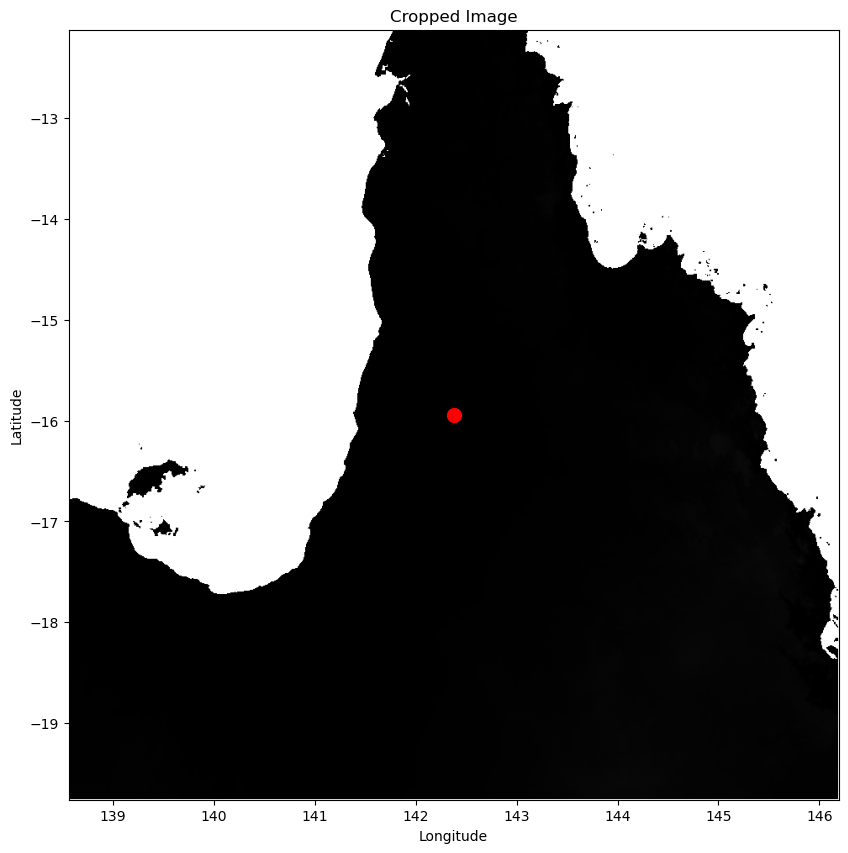

In [83]:
# Call the function to crop the DEM around the pour point
crop_dem(dem, output_tif, lon, lat,area)

### Delineate Basin from Cropped DEM

In [84]:
# Load the .tif file for the DEM
tif_input = output_tif
pour_point = [lon,lat]
print(pour_point)

# Define the path for the new shapefile
new_folder_path = f'/global/scratch/users/slsmit34/299/STATIONS/{number}/'

# Create the folder and filepath
os.makedirs(new_folder_path, exist_ok=True)
shp_name = new_folder_path + f'{number}.shp'

[142.374, -15.9424]


In [85]:
# Initialize a grid from the raster
grid = Grid.from_raster(tif_input, data_name='dem')
dem = grid.read_raster(tif_input)

In [86]:
# Condition DEM
# ----------------------
# Fill pits in DEM
pit_filled_dem = grid.fill_pits(dem)

# Fill depressions in DEM
flooded_dem = grid.fill_depressions(pit_filled_dem)
    
# Resolve flats in DEM
inflated_dem = grid.resolve_flats(flooded_dem)

In [87]:
# Define the flow direction map (Dirmap)
dir_map = (64, 128, 1, 2, 4, 8, 16, 32)

# Compute flow directions from DEM
f_dir = grid.flowdir(inflated_dem, dirmap=dir_map)  # returns a Raster object
print(np.nanmin(f_dir))

-2


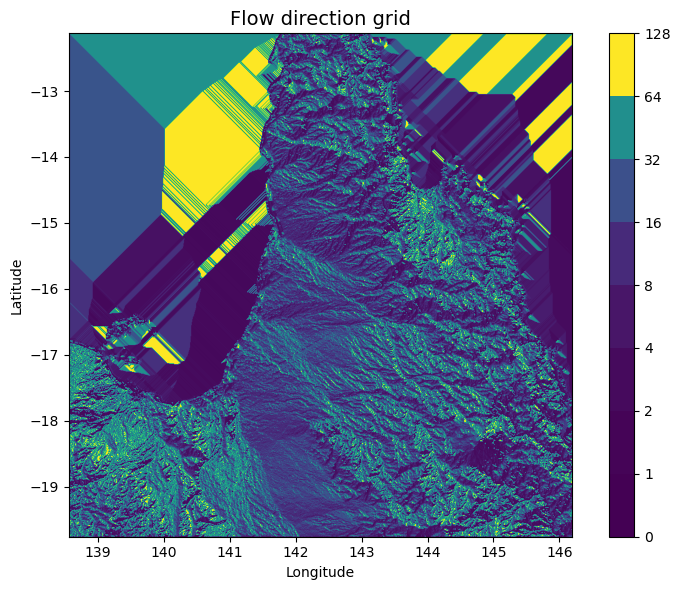

In [88]:
# Plot the flow direction map
fig = plt.figure(figsize=(8,6))
fig.patch.set_alpha(0)

plt.imshow(f_dir, extent=grid.extent, cmap='viridis', zorder=2)
plt.scatter(lon, lat, color='red', marker='o', s=100, label="Center Point")
boundaries = ([0] + sorted(list(dir_map)))
plt.colorbar(boundaries= boundaries,
             values=sorted(dir_map))
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Flow direction grid', size=14)
plt.grid(zorder=-1)
plt.tight_layout()

## Calculate accumulation and define snap points

In [89]:
acc = grid.accumulation(f_dir, dirmap=dir_map)
acc[dem==0] = 0

## Delineate Basin

In [90]:
# Convert lon/lat to raster indices
row, col = rowcol(acc.affine, lon, lat)
# Access the accumulation value
acc_atpt = acc.view()[row, col]
acc_max = int(acc.max())

In [91]:
arr = acc.view()

# Define half-window size (9x9 = 4 px in each direction)
half_size = 4

# Create a window around the pour-point to snap to
row_start = max(0, row - half_size)
row_end   = min(arr.shape[0], row + half_size + 1)
col_start = max(0, col - half_size)
col_end   = min(arr.shape[1], col + half_size + 1)

# Extract the window
window = arr[row_start:row_end, col_start:col_end]

In [92]:
# SAVE THESE METRICS
print("Flow accumulation at point: ", acc_atpt)
print("Max accumulation: ", acc_max)
print("Average of full area: ", ((acc_max+acc_atpt)/2))
print("Window shape:", window.shape)
print("Max accumulation in 9x9: ", np.max(window)) 
print("Avg accumulation in 9x9: ", np.mean(window)) 

Flow accumulation at point:  1.0
Max accumulation:  74824
Average of full area:  37412.5
Window shape: (9, 9)
Max accumulation in 9x9:  55381.0
Avg accumulation in 9x9:  2055.1604938271603


In [93]:
# Define the accumulation of the snapped point
snap_pt = np.max(window)

In [94]:
x_snap, y_snap = grid.snap_to_mask(acc > snap_pt, (lon, lat))
catch = grid.catchment(x=x_snap, y=y_snap, fdir=f_dir, dirmap=dir_map,
                          xytype='coordinate')

# Convert lon/lat to raster indices
row_snap, col_snap = rowcol(acc.affine, x_snap, y_snap)
# Access the accumulation value
acc_snapped = acc.view()[row_snap, col_snap]
print(np.size(acc))
print(lon,lat)
print(x_snap, y_snap)
print("Accumulation at snapped point: ", acc_snapped)

839056
142.374 -15.9424
142.37499999999997 -15.98333333333289
Accumulation at snapped point:  1.0


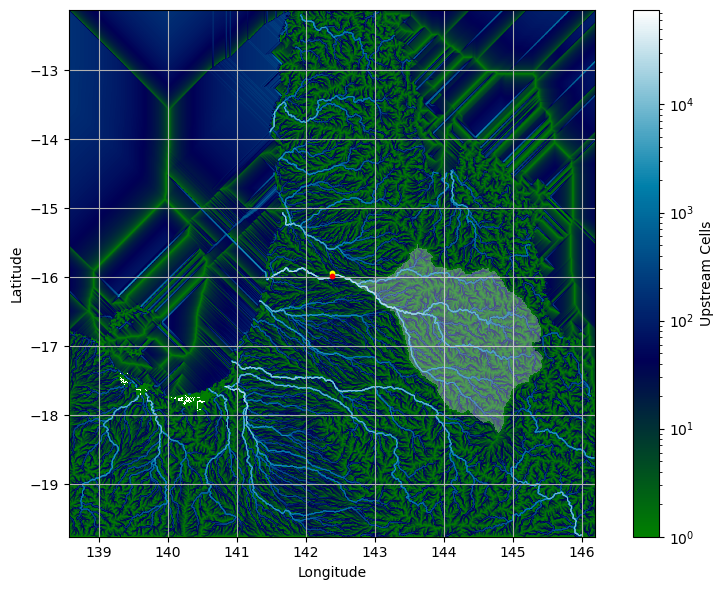

In [95]:
# # Clip the bounding box to the catchment
# grid.clip_to(catch)
catch_view = grid.view(catch, dtype=np.uint8)

fig, ax = plt.subplots(figsize=(8,6))
fig.patch.set_alpha(0)
plt.grid('on', zorder=0)
im = ax.imshow(acc, extent=catch.extent, zorder=1,
                cmap='ocean',
                norm=colors.LogNorm(1, acc.max()),
                interpolation='bilinear')
plt.colorbar(im, ax=ax, label='Upstream Cells')
plt.imshow(np.where(catch_view,catch_view, np.nan), extent=grid.extent,zorder=2, cmap='Greys',alpha=0.3)
plt.scatter(lon,lat, color='yellow', s=10, marker='o', zorder=3)
plt.scatter(x_snap,y_snap, color='red', s=10, marker='o', zorder=3)
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.tight_layout()
plt.show()

## Compare delineated and GRDC shapefiles

In [96]:
# Create a vector representation of the catchment mask
shapes = grid.polygonize(catch_view)

# Specify schema
schema = {
        'geometry': 'Polygon',
        'properties': {'LABEL': 'float:16'}
}

def extract_holes(geom):
    """Return holes (interior rings) as polygons."""
    holes = []
    if geom.geom_type == "Polygon":
        for interior in geom.interiors:
            holes.append(Polygon(interior))
    elif geom.geom_type == "MultiPolygon":
        for poly in geom.geoms:
            for interior in poly.interiors:
                holes.append(Polygon(interior))
    return holes

# Write shapefile of the delineated catchment
shp_output = shp_name
with fiona.open(
    shp_output,
    'w',
    driver='ESRI Shapefile',
    crs=grid.crs.srs,
    schema=schema
) as c:
    i = 0
    for geom, value in shapes:
        g = shape(geom)

        # Extract interior rings (the regions you actually want)
        holes = extract_holes(g)

        # If no holes, just write the geometry itself
        if not holes:
            rec = {
                "geometry": g.__geo_interface__,
                "properties": {"LABEL": str(value)},
                "id": str(i),
            }
            c.write(rec)
            i += 1
        else:
            # Write each hole as its own polygon feature
            for h in holes:
                rec = {
                    "geometry": h.__geo_interface__,
                    "properties": {"LABEL": str(value)},
                    "id": str(i),
                }
                c.write(rec)
                i += 1


In [97]:
# EXAMPLE: 
delin_shp = gpd.read_file(shp_output) # delineated shapefile
grdc_shp = gpd.read_file(f'/global/scratch/users/cgerlein/fc_ecohydrology_scratch/CSMUB/DATA/SHAPEFILES/{number}/{number}.shp') # GRDC shapefile
projected_crs = grdc_shp.to_crs(epsg=32618)#32633) #32618  # Use an appropriate EPSG for your region
#delin_shp = delin_shp.to_crs(projected_crs.crs)
grdc_shp = grdc_shp.to_crs(projected_crs.crs)
grdc_shp

,grdc_no,river,station,area,altitude,lat_org,long_org,lat_pp,long_pp,dist_km,area_calc,quality,type,comment,source,geometry
0,5109201.0,MITCHELL RIVER,DUNBAR,45000.0,19.71,-15.9424,142.374,-15.9438,142.3771,0.4,45874.4,High,Automatic,Area difference <= 5% and distance <= 5 km,hydrosheds,"MULTIPOLYGON (((-3935024.677 -17832270.527, -3..."


In [101]:
# Read the shapefiles
delin_shp = gpd.read_file(shp_output) # delineated shapefile
# shapefile1 = catch_view
grdc_shp = gpd.read_file(f'/global/scratch/users/cgerlein/fc_ecohydrology_scratch/CSMUB/DATA/SHAPEFILES/{number}/{number}.shp') # GRDC shapefile

# Step 3: Reproject to a projected CRS (e.g., UTM Zone 33N, replace EPSG:32633 as appropriate)
projected_crs = grdc_shp.to_crs(epsg=32618)#32633)  # Use an appropriate EPSG for your region
delin_shp = delin_shp.to_crs(projected_crs.crs)
grdc_shp = grdc_shp.to_crs(projected_crs.crs)

# Calculate the intersection
intersection = gpd.overlay(delin_shp.dissolve(), grdc_shp.dissolve(), how='intersection')
print(intersection)

# Calculate the area of the intersection
intersection_area = intersection.geometry.area

print(intersection_area[0]/10**6) # 10^6 conversion for m2 to km2
print(area)

   LABEL    grdc_no           river station     area  altitude  lat_org  \
0      1  5109201.0  MITCHELL RIVER  DUNBAR  45000.0     19.71 -15.9424   

   long_org   lat_pp   long_pp  dist_km  area_calc quality       type  \
0   142.374 -15.9438  142.3771      0.4    45874.4    High  Automatic   

                                      comment      source  \
0  Area difference <= 5% and distance <= 5 km  hydrosheds   

                                            geometry  
0  MULTIPOLYGON (((-3760711.139 -17799619.186, -3...  
71430.9465900886
45000.0


In [102]:
# Calculate the percent of area intersected between the two shapefiles
inter_pcnt = ((intersection_area[0]/10**6)/area)*100 # NEED TO FIX
print("Intersection percentage:", inter_pcnt)

# if inter_pcnt >= 50:
#   shapefile = shp_output
#   shp_log[i] = 1

# else:
#     shapefile = f'/global/scratch/users/arvalcarcel/CSMUB/DATA/SHAPEFILES/{number}/{number}.shp'
#     shp_log[i] = 2

# grdc_shp = shp_log[shp_log == 2]
# print("Number of GRDC Shapefiles used: ", len(grdc_shp))

Intersection percentage: 158.73543686686355


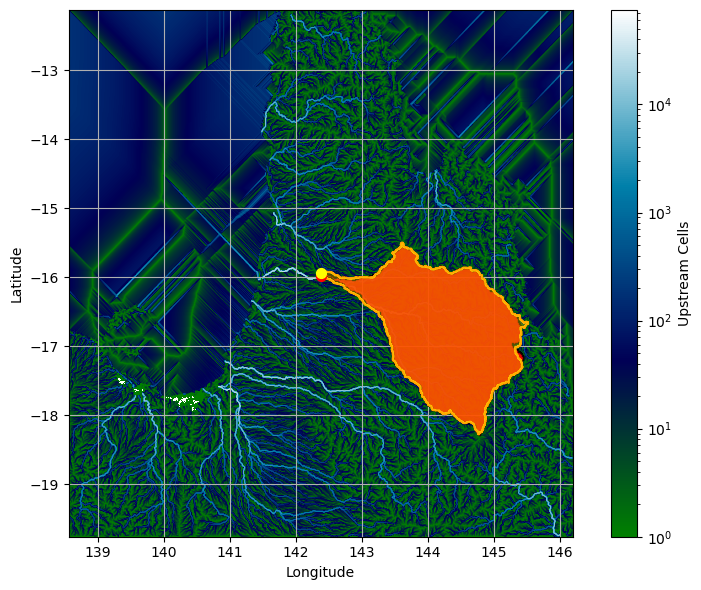

In [100]:
# Load shapefiles as gdfs
gdf_delin = gpd.read_file(shp_output)
gdf_grdc = gpd.read_file(f'/global/scratch/users/cgerlein/fc_ecohydrology_scratch/CSMUB/DATA/SHAPEFILES/{number}/{number}.shp')

fig, ax = plt.subplots(figsize=(8,6))
fig.patch.set_alpha(0)

# Flow accumulation background
im = ax.imshow(
    acc,
    extent=catch.extent,
    zorder=1,
    cmap="ocean",
    norm=colors.LogNorm(1, acc.max()),
    interpolation="bilinear"
)

# Colorbar
plt.colorbar(im, ax=ax, label="Upstream Cells")

# Overlay shapefiles instead of NaN mask
gdf_delin.boundary.plot(ax=ax, edgecolor="black", linewidth=1.5, zorder=2)
gdf_delin.plot(ax=ax, facecolor="red", edgecolor="black", alpha=0.7, zorder=2)

gdf_grdc.boundary.plot(ax=ax, edgecolor="orange", linewidth=1.5, zorder=2)
gdf_grdc.plot(ax=ax, facecolor="yellow", edgecolor="orange", alpha=0.3, zorder=2)

# Snap point
ax.scatter(x_snap, y_snap, color="red", s=50, marker="o", zorder=3)
ax.scatter(lon, lat, color="yellow", s=50, marker="o", zorder=3)

# Labels, formatting
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.grid(True, zorder=0)
# ADD A LEGEND


plt.tight_layout()
plt.show()


## OPTIONAL: Visualize delineated basin shapefile

In [26]:
# # Load shapefile
# shp = gpd.read_file(shapefile).to_crs("EPSG:4326")

# def extract_holes(geom):
#     holes = []
#     if geom.geom_type == 'Polygon':
#         for interior in geom.interiors:
#             holes.append(Polygon(interior))
#     elif geom.geom_type == 'MultiPolygon':
#         for poly in geom.geoms:
#             for interior in poly.interiors:
#                 holes.append(Polygon(interior))
#     return holes

# # Collect holes from all geometries
# holes = []
# for g in shp.geometry:
#     holes.extend(extract_holes(g))

# # Decide what to plot
# if holes:  # If we found holes, use them
#     gdf_to_plot = gpd.GeoDataFrame(geometry=holes, crs=shp.crs)
#     title = "Shapefile Visualization (holes)"
# else:      # Otherwise, just use the shapefile as-is
#     gdf_to_plot = shp
#     title = "Shapefile Visualization (No Holes Detected)"

# # Plot
# ax = gdf_to_plot.plot(facecolor="blue", edgecolor="black", figsize=(6,6))
# ax.set_title(title)
# ax.set_xlabel("Longitude")
# ax.set_ylabel("Latitude")

## OPTIONAL: Generate random points and delineate basin

In [27]:
yi_s = np.random.randint(0, grid.shape[0], size=10)
xi_s = np.random.randint(0, grid.shape[1], size=10)
xs, ys = grid.affine * (xi_s, yi_s)

In [28]:
z0 = np.zeros(grid.shape)
i = 0

for x, y in zip(xs, ys):
    i += 1
    c = grid.catchment(x=x, y=y, fdir=fdir, dirmap=dirmap, xytype='label', inplace=False)
    z0 += i * (c != 0).astype(int)

NameError: name 'fdir' is not defined

## OPTIONAL: Delineate basin from snapped points

In [ ]:
# x_snap, y_snap = grid.snap_to_mask(acc > snap_pt, xy)
new_xy = grid.snap_to_mask(acc > snap_pt, xy, return_dist=False)
new_xs, new_ys = new_xy[:,0], new_xy[:,1]

In [ ]:
z1 = np.zeros(grid.shape)
i = 0

for x, y in zip(new_xs, new_ys):
    i += 1
    c = grid.catchment(x, y, fdir=fdir, dirmap=dirmap, xytype='label', inplace=False)
    z1 += i * (c != 0).astype(int)

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

z0[z0 == 0] = np.nan
z1[z1 == 0] = np.nan

ax[0].imshow(z0, extent=grid.extent, zorder=1, cmap='plasma')
ax[0].scatter(xy[:,0], xy[:,1], marker='x', c='k', zorder=2)
ax[0].set_title('Catchments at original coordinates')
ax[0].set_xlabel('Longitude')
ax[0].set_ylabel('Latitude')

ax[1].imshow(z1, extent=grid.extent, zorder=1, cmap='plasma')
ax[1].scatter(new_xy[:,0], new_xy[:,1], marker='x', c='k', zorder=2)
ax[1].set_title('Catchments at snapped coordinates')
ax[1].set_xlabel('Longitude')

plt.tight_layout()

In [ ]:
fig, ax = plt.subplots(figsize=(8,8))
ax.set_aspect('equal')

plt.scatter(xs, ys, marker='x', c='b', s=100, label='original')
plt.scatter(new_xs, new_ys, marker='x', c='r', s=100, label='snapped')
plt.legend(frameon=True)
plt.imshow(np.where(acc > 100, 1, np.nan), extent=grid.extent, cmap='bone', zorder=1, alpha=0.8)
plt.title('Original vs. snapped coordinates')
plt.xlabel('Longitude')
plt.ylabel('Latitude')